# Elo Score trends

Plotting Elo ratings for: Cnamuangtoun Subset 5 Copy
Guard models: ['gemini-2.0-flash-001', 'llama-3.1-8b-instruct', 'llama-3.3-70b-instruct', 'chatgpt-4o-latest']
Houdini models: ['gemini-2.0-flash-001', 'llama-3.1-8b-instruct', 'llama-3.3-70b-instruct', 'chatgpt-4o-latest']
Best model: linear_both_cut
R²: 0.9881
COL MEAN Best Model Name: linear_both_cut
COL MEAN Best-Fit Parameters: [680.7667194716846, 1119.0598458754184, 1283.5058720155387, 1350.1665580735735]
              linear  AIC=-13.92,  SSR=0.05
    linear_upper_cut  AIC=-12.59,  SSR=0.04
    linear_lower_cut  AIC=-14.25,  SSR=0.03
     linear_both_cut  AIC=-22.05,  SSR=0.00
Best model: linear
R²: 0.9874
ROW MEAN Best Model Name: linear
ROW MEAN Best-Fit Parameters: [-4.43247814506101, 7274.373477550722]
              linear  AIC=-19.72,  SSR=0.01
    linear_upper_cut  AIC=-1.96,  SSR=0.55
    linear_lower_cut  AIC=-17.72,  SSR=0.01
     linear_both_cut  AIC=0.70,  SSR=0.64


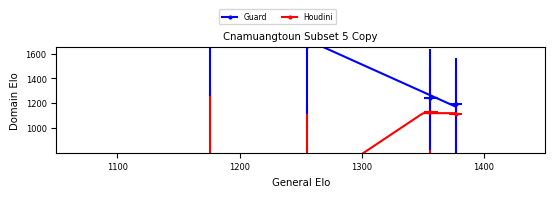

Figure saved successfully to ./figures/


In [5]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from elo_utils import plot_elo_standard  # Only need the plotting function

# Load your pre-calculated Elo data
with open('../data/domain_elos/cnamuangtoun_subset_5_copy.json', 'r') as f:
    data = json.load(f)

# Extract the pre-calculated Elo bounds
guard_models = data['guard_models']
houdini_models = data['houdini_models']

# Convert lists back to numpy arrays
row_mean = np.array(data['guard_elos']['mean'])
row_low = np.array(data['guard_elos']['low'])
row_high = np.array(data['guard_elos']['high'])

col_mean = np.array(data['houdini_elos']['mean'])
col_low = np.array(data['houdini_elos']['low'])
col_high = np.array(data['houdini_elos']['high'])

# Create a mapping from your model names to llm_elos.csv names
MODEL_NAME_MAPPING = {
    "google/gemini-2.0-flash-001": "gemini-2.0-flash-001",
    "meta-llama/llama-3.1-8b-instant": "llama-3.1-8b-instruct",
    "meta-llama/llama-3.3-70b-instruct": "llama-3.3-70b-instruct",
    "openai/gpt-4o": "chatgpt-4o-latest"
}

# Map your model names to the ones in llm_elos.csv
guard_models = [MODEL_NAME_MAPPING.get(m, m) for m in guard_models]
houdini_models = [MODEL_NAME_MAPPING.get(m, m) for m in houdini_models]


# Get game name from dataset field
dataset_name = data.get('dataset', 'Resume Selection')
# Clean up the name if it has .json extension
game_name = dataset_name.replace('.json', '').replace('_', ' ').title()

print(f"Plotting Elo ratings for: {game_name}")
print(f"Guard models: {guard_models}")
print(f"Houdini models: {houdini_models}")

# Set up plotting parameters
with plt.rc_context({
    'font.family': 'sans-serif',
    'font.size': 5,
    'axes.labelsize': 7.25,
    'axes.titlesize': 7.25,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 5.5,
}):
    # Create a single subplot for this game
    fig, ax = plt.subplots(1, 1, figsize=(5.5, 1.8))

    # Plot the Elo curves
    plot_elo_standard(
        row_mean, row_low, row_high,
        col_mean, col_low, col_high,
        collabel='Guard',      # Keep original labels or change to 'Recruiter'
        rowlabel='Houdini',    # Keep original labels or change to 'Candidate'
        gamename=game_name,
        ax=ax,
        model_list=guard_models
        # models_to_ignore=['model-name']  # Add specific models to ignore if needed
    )

    # Create legend handles
    guard_handle = mlines.Line2D([], [], color='blue', marker='o',
                                 linestyle='-', markersize=2,
                                 label='Guard')
    houdini_handle = mlines.Line2D([], [], color='red', marker='o',
                                   linestyle='-', markersize=2,
                                   label='Houdini')

    # Add a global legend to the figure
    fig.legend(handles=[guard_handle, houdini_handle],
              loc='upper center',
              ncol=2,
              bbox_to_anchor=(0.5, 1.05))

    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.95])


    plt.show()

print("Figure saved successfully to ./figures/")

# Issues
- Large error bars (uncertainty ranges): The confidence intervals are very wide
- The x-axis (General Elo) values are very close

Plotting Elo ratings for: Cnamuangtoun Subset 5 Copy
Guard models: ['gemini-2.0-flash-001', 'llama-3.1-8b-instruct', 'llama-3.3-70b-instruct', 'chatgpt-4o-latest']
Houdini models: ['gemini-2.0-flash-001', 'llama-3.1-8b-instruct', 'llama-3.3-70b-instruct', 'chatgpt-4o-latest']
Best model: linear_both_cut
R²: 0.9881
COL MEAN Best Model Name: linear_both_cut
COL MEAN Best-Fit Parameters: [680.7667194716846, 1119.0598458754184, 1283.5058720155387, 1350.1665580735735]
              linear  AIC=-13.92,  SSR=0.05
    linear_upper_cut  AIC=-12.59,  SSR=0.04
    linear_lower_cut  AIC=-14.25,  SSR=0.03
     linear_both_cut  AIC=-22.05,  SSR=0.00
Best model: linear
R²: 0.9874
ROW MEAN Best Model Name: linear
ROW MEAN Best-Fit Parameters: [-4.43247814506101, 7274.373477550722]
              linear  AIC=-19.72,  SSR=0.01
    linear_upper_cut  AIC=-1.96,  SSR=0.55
    linear_lower_cut  AIC=-17.72,  SSR=0.01
     linear_both_cut  AIC=0.70,  SSR=0.64


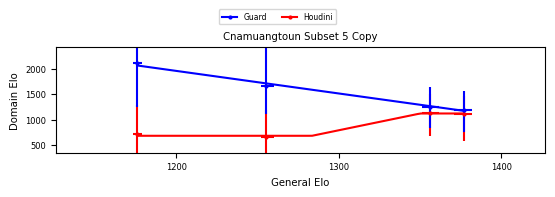

Figure saved successfully to ./figures/


In [6]:
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
from elo_utils import plot_elo_standard_B  # Only need the plotting function

# Load your pre-calculated Elo data
with open('../data/domain_elos/cnamuangtoun_subset_5_copy.json', 'r') as f:
    data = json.load(f)

# Extract the pre-calculated Elo bounds
guard_models = data['guard_models']
houdini_models = data['houdini_models']

# Convert lists back to numpy arrays
row_mean = np.array(data['guard_elos']['mean'])
row_low = np.array(data['guard_elos']['low'])
row_high = np.array(data['guard_elos']['high'])

col_mean = np.array(data['houdini_elos']['mean'])
col_low = np.array(data['houdini_elos']['low'])
col_high = np.array(data['houdini_elos']['high'])

# Create a mapping from your model names to llm_elos.csv names
MODEL_NAME_MAPPING = {
    "google/gemini-2.0-flash-001": "gemini-2.0-flash-001",
    "meta-llama/llama-3.1-8b-instant": "llama-3.1-8b-instruct",
    "meta-llama/llama-3.3-70b-instruct": "llama-3.3-70b-instruct",
    "openai/gpt-4o": "chatgpt-4o-latest"
}

# Map your model names to the ones in llm_elos.csv
guard_models = [MODEL_NAME_MAPPING.get(m, m) for m in guard_models]
houdini_models = [MODEL_NAME_MAPPING.get(m, m) for m in houdini_models]


# Get game name from dataset field
dataset_name = data.get('dataset', 'Resume Selection')
# Clean up the name if it has .json extension
game_name = dataset_name.replace('.json', '').replace('_', ' ').title()

print(f"Plotting Elo ratings for: {game_name}")
print(f"Guard models: {guard_models}")
print(f"Houdini models: {houdini_models}")

# Set up plotting parameters
with plt.rc_context({
    'font.family': 'sans-serif',
    'font.size': 5,
    'axes.labelsize': 7.25,
    'axes.titlesize': 7.25,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 5.5,
}):
    # Create a single subplot for this game
    fig, ax = plt.subplots(1, 1, figsize=(5.5, 1.8))

    # Plot the Elo curves
    plot_elo_standard_B(
        row_mean, row_low, row_high,
        col_mean, col_low, col_high,
        collabel='Guard',      # Keep original labels or change to 'Recruiter'
        rowlabel='Houdini',    # Keep original labels or change to 'Candidate'
        gamename=game_name,
        ax=ax,
        model_list=guard_models
        # models_to_ignore=['model-name']  # Add specific models to ignore if needed
    )

    # Create legend handles
    guard_handle = mlines.Line2D([], [], color='blue', marker='o',
                                 linestyle='-', markersize=2,
                                 label='Guard')
    houdini_handle = mlines.Line2D([], [], color='red', marker='o',
                                   linestyle='-', markersize=2,
                                   label='Houdini')

    # Add a global legend to the figure
    fig.legend(handles=[guard_handle, houdini_handle],
              loc='upper center',
              ncol=2,
              bbox_to_anchor=(0.5, 1.05))

    # Adjust layout
    plt.tight_layout(rect=[0, 0, 1, 0.95])


    plt.show()

print("Figure saved successfully to ./figures/")

## Issues:
- Guard models show a downward trend

# Global Win Rate

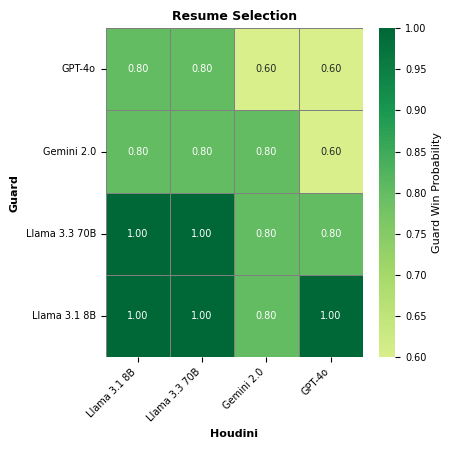

Multi-game heatmap saved successfully!

Win rate statistics by game:

Resume Selection:
  Mean: 0.825
  Min:  0.600
  Max:  1.000


In [7]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Define your games/datasets
game_datasets = [
    "cnamuangtoun_subset_5_copy.json",
    # Add more dataset files here if you have multiple experiments
    # "another_dataset.json",
    # "third_dataset.json",
]

game_id_to_gamename_map = {
    "cnamuangtoun_subset_5_copy.json": "Resume Selection",
    # Add more mappings here
}

# Load general Elo scores from CSV
llm_elos_df = pd.read_csv('../elo/llm_elos.csv')
llm_elos_dict = dict(zip(llm_elos_df['llm_name'], llm_elos_df['elo']))

# Model name mapping (from your JSON format to llm_elos.csv format)
MODEL_NAME_MAPPING = {
    'google/gemini-2.0-flash-001': 'gemini-2.0-flash-001',
    'meta-llama/llama-3.1-8b-instant': 'llama-3.1-8b-instruct',
    'meta-llama/llama-3.3-70b-instruct': 'llama-3.3-70b-instruct',
    'openai/gpt-4o': 'chatgpt-4o-latest'
}

def clean_model_name(name):
    """Shorten model names for better display"""
    name_map = {
        'google/gemini-2.0-flash-001': 'Gemini 2.0',
        'meta-llama/llama-3.1-8b-instant': 'Llama 3.1 8B',
        'meta-llama/llama-3.3-70b-instruct': 'Llama 3.3 70B',
        'openai/gpt-4o': 'GPT-4o'
    }
    return name_map.get(name, name.split('/')[-1])

def get_general_elo(model_name):
    """Get general Elo for a model from llm_elos.csv"""
    mapped_name = MODEL_NAME_MAPPING.get(model_name, model_name)
    return llm_elos_dict.get(mapped_name, 0)

# Load all datasets
game_data = {}
for dataset_file in game_datasets:
    dataset_path = f'../data/win_rates/{dataset_file}'

    with open(dataset_path) as file:
        data = json.load(file)

    df = pd.DataFrame(data)

    # Create win rate matrix
    win_rate_df = df.pivot_table(
        values='guard_win_prob', index='guard', columns='houdini'
    )

    # Sort by general Elo before cleaning names
    guard_order = sorted(win_rate_df.index, key=get_general_elo, reverse=True)  # Strongest at top
    houdini_order = sorted(win_rate_df.columns, key=get_general_elo)  # Strongest at right

    # Reorder the dataframe
    win_rate_df = win_rate_df.loc[guard_order, houdini_order]

    # Clean model names
    win_rate_df.index = [clean_model_name(x) for x in win_rate_df.index]
    win_rate_df.columns = [clean_model_name(x) for x in win_rate_df.columns]

    game_data[dataset_file] = win_rate_df

# Set up plotting parameters
num_games = len(game_datasets)

with plt.rc_context({
    'font.family': 'sans-serif',
    'font.size': 7,
    'axes.labelsize': 8,
    'axes.titlesize': 9,
    'xtick.labelsize': 7,
    'ytick.labelsize': 7,
}):
    # Adjust figure size based on number of games
    fig_width = 4.5 * num_games
    fig, axes = plt.subplots(1, num_games, figsize=(fig_width, 4.5))

    # Handle single game case
    if num_games == 1:
        axes = [axes]

    # Find global min/max for consistent color scale
    all_values = np.concatenate([df.values.flatten() for df in game_data.values()])
    vmin = np.nanmin(all_values)
    vmax = np.nanmax(all_values)

    for i, (game_id, win_rate_df) in enumerate(game_data.items()):
        # Create heatmap
        sns.heatmap(
            win_rate_df,
            annot=True,
            fmt='.2f',
            cmap='RdYlGn',
            center=0.5,
            vmin=vmin,
            vmax=vmax,
            cbar=(i == num_games - 1),  # Only show colorbar on last subplot
            cbar_kws={'label': 'Guard Win Probability'} if i == num_games - 1 else None,
            linewidths=0.5,
            linecolor='gray',
            ax=axes[i]
        )

        # Set title
        game_name = game_id_to_gamename_map.get(game_id, game_id)
        axes[i].set_title(game_name, fontweight='bold')

        # Labels
        axes[i].set_xlabel('Houdini', fontweight='bold')
        if i == 0:
            axes[i].set_ylabel('Guard', fontweight='bold')
        else:
            axes[i].set_ylabel('')

        # Rotate x-axis labels
        axes[i].set_xticklabels(axes[i].get_xticklabels(), rotation=45, ha='right')
        axes[i].set_yticklabels(axes[i].get_yticklabels(), rotation=0)

    # Adjust layout
    plt.tight_layout()


    plt.show()

print("Multi-game heatmap saved successfully!")
print("\nWin rate statistics by game:")
for game_id, win_rate_df in game_data.items():
    game_name = game_id_to_gamename_map.get(game_id, game_id)
    print(f"\n{game_name}:")
    print(f"  Mean: {win_rate_df.values.mean():.3f}")
    print(f"  Min:  {np.nanmin(win_rate_df.values):.3f}")
    print(f"  Max:  {np.nanmax(win_rate_df.values):.3f}")

# Guard Win Rate Bar Chart

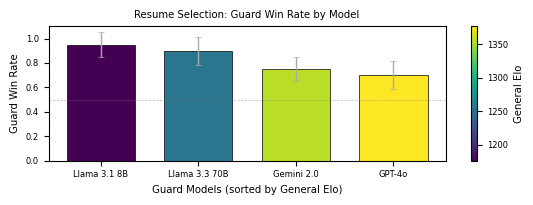

GUARD WIN RATE STATISTICS
Llama 3.1 8B    | Gen Elo: 1176 | Win Rate: 0.950
Llama 3.3 70B   | Gen Elo: 1255 | Win Rate: 0.900
Gemini 2.0      | Gen Elo: 1356 | Win Rate: 0.750
GPT-4o          | Gen Elo: 1377 | Win Rate: 0.700


In [12]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load general Elo scores from CSV
llm_elos_df = pd.read_csv('../elo/llm_elos.csv')
llm_elos_dict = dict(zip(llm_elos_df['llm_name'], llm_elos_df['elo']))

# Model name mapping
MODEL_NAME_MAPPING = {
    'google/gemini-2.0-flash-001': 'gemini-2.0-flash-001',
    'meta-llama/llama-3.1-8b-instant': 'llama-3.1-8b-instruct',
    'meta-llama/llama-3.3-70b-instruct': 'llama-3.3-70b-instruct',
    'openai/gpt-4o': 'chatgpt-4o-latest'
}

def clean_model_name(name):
    """Shorten model names for better display"""
    name_map = {
        'google/gemini-2.0-flash-001': 'Gemini 2.0',
        'meta-llama/llama-3.1-8b-instant': 'Llama 3.1 8B',
        'meta-llama/llama-3.3-70b-instruct': 'Llama 3.3 70B',
        'openai/gpt-4o': 'GPT-4o'
    }
    return name_map.get(name, name.split('/')[-1])

def get_general_elo(model_name):
    """Get general Elo for a model from llm_elos.csv"""
    mapped_name = MODEL_NAME_MAPPING.get(model_name, model_name)
    return llm_elos_dict.get(mapped_name, 0)

# Load the win rate data
dataset_path = '../data/win_rates/cnamuangtoun_subset_5_copy.json'

with open(dataset_path) as file:
    data = json.load(file)

df = pd.DataFrame(data)

# Calculate average win rate for each guard model
guard_win_rates = df.groupby('guard')['guard_win_prob'].mean().to_dict()

# Get list of guard models and sort by general Elo
guard_models = list(guard_win_rates.keys())
guard_models_sorted = sorted(guard_models, key=get_general_elo)

# Prepare data for plotting
model_labels = [clean_model_name(m) for m in guard_models_sorted]
win_rates = [guard_win_rates[m] for m in guard_models_sorted]
elo_scores = [get_general_elo(m) for m in guard_models_sorted]

# Calculate standard errors (optional - based on variance across matchups)
guard_win_stds = df.groupby('guard')['guard_win_prob'].std().to_dict()
win_rate_errors = [guard_win_stds.get(m, 0) for m in guard_models_sorted]

# Set up color mapping based on general Elo
cmap = plt.cm.viridis
norm = plt.Normalize(min(elo_scores), max(elo_scores))
colors = [cmap(norm(elo)) for elo in elo_scores]

# Create the bar chart
with plt.rc_context({
    'font.family': 'sans-serif',
    'font.size': 5,
    'axes.labelsize': 7.25,
    'axes.titlesize': 7.25,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 5.5,
}):
    fig, ax = plt.subplots(1, 1, figsize=(5.5, 2))

    # Bar positions
    positions = np.arange(len(guard_models_sorted))

    # Create bars
    bars = ax.bar(
        positions,
        win_rates,
        width=0.7,
        color=colors,
        edgecolor='black',
        linewidth=0.5
    )

    # Add error bars
    ax.errorbar(
        positions,
        win_rates,
        yerr=win_rate_errors,
        fmt='none',
        ecolor='#AAAAAA',
        capsize=2,
        elinewidth=1,
        capthick=0.5,
    )

    # Customize axes
    ax.set_xticks(positions)
    ax.set_xticklabels(model_labels, rotation=0)
    ax.set_ylabel('Guard Win Rate')
    ax.set_xlabel('Guard Models (sorted by General Elo)')
    ax.set_title('Resume Selection: Guard Win Rate by Model')

    # Set y-axis limits
    ax.set_ylim(0, 1.1)
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    # Add colorbar to show General Elo mapping
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('General Elo')

    plt.tight_layout()


    plt.show()

# Print statistics
print("="*60)
print("GUARD WIN RATE STATISTICS")
print("="*60)
for model, label, elo, win_rate in zip(guard_models_sorted, model_labels, elo_scores, win_rates):
    print(f"{label:15s} | Gen Elo: {elo:4d} | Win Rate: {win_rate:.3f}")

## Fixed Houdini

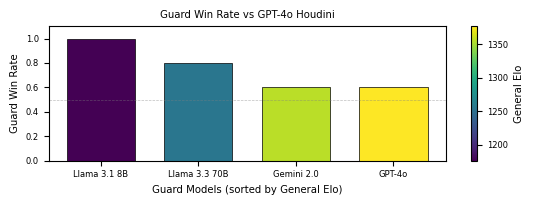

GUARD WIN RATE vs GPT-4o HOUDINI
Llama 3.1 8B    | Gen Elo: 1176 | Win Rate: 1.000
Llama 3.3 70B   | Gen Elo: 1255 | Win Rate: 0.800
Gemini 2.0      | Gen Elo: 1356 | Win Rate: 0.600
GPT-4o          | Gen Elo: 1377 | Win Rate: 0.600


In [21]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load general Elo scores from CSV
llm_elos_df = pd.read_csv('../elo/llm_elos.csv')
llm_elos_dict = dict(zip(llm_elos_df['llm_name'], llm_elos_df['elo']))

# Model name mapping
MODEL_NAME_MAPPING = {
    'google/gemini-2.0-flash-001': 'gemini-2.0-flash-001',
    'meta-llama/llama-3.1-8b-instant': 'llama-3.1-8b-instruct',
    'meta-llama/llama-3.3-70b-instruct': 'llama-3.3-70b-instruct',
    'openai/gpt-4o': 'chatgpt-4o-latest'
}

def clean_model_name(name):
    """Shorten model names for better display"""
    name_map = {
        'google/gemini-2.0-flash-001': 'Gemini 2.0',
        'meta-llama/llama-3.1-8b-instant': 'Llama 3.1 8B',
        'meta-llama/llama-3.3-70b-instruct': 'Llama 3.3 70B',
        'openai/gpt-4o': 'GPT-4o'
    }
    return name_map.get(name, name.split('/')[-1])

def get_general_elo(model_name):
    """Get general Elo for a model from llm_elos.csv"""
    mapped_name = MODEL_NAME_MAPPING.get(model_name, model_name)
    return llm_elos_dict.get(mapped_name, 0)

# Load the win rate data
dataset_path = '../data/win_rates/cnamuangtoun_subset_5_copy.json'

with open(dataset_path) as file:
    data = json.load(file)

df = pd.DataFrame(data)

# Choose which Houdini model to analyze
# Options: 'google/gemini-2.0-flash-001', 'meta-llama/llama-3.1-8b-instant',
#          'meta-llama/llama-3.3-70b-instruct', 'openai/gpt-4o'
FIXED_HOUDINI = 'openai/gpt-4o'  # Change this to analyze different Houdinis

# Filter data for the fixed Houdini
houdini_data = df[df['houdini'] == FIXED_HOUDINI]

# Get Guard win rates
guard_win_rates = houdini_data.groupby('guard').agg({
    'guard_win_prob': 'mean'
}).reset_index()
guard_win_rates.columns = ['guard', 'win_rate']

# Get list of Guard models and sort by general Elo
guard_models = guard_win_rates['guard'].tolist()
guard_models_sorted = sorted(guard_models, key=get_general_elo)

# Prepare data for plotting
model_labels = [clean_model_name(m) for m in guard_models_sorted]
win_rates = [guard_win_rates[guard_win_rates['guard'] == m]['win_rate'].values[0]
             for m in guard_models_sorted]
elo_scores = [get_general_elo(m) for m in guard_models_sorted]

# Calculate standard errors (based on variance across games with this Houdini)
guard_stds = houdini_data.groupby('guard')['guard_win_prob'].std().to_dict()
win_rate_errors = [guard_stds.get(m, 0) for m in guard_models_sorted]

# Set up color mapping based on general Elo (same as other charts)
cmap = plt.cm.viridis
norm = plt.Normalize(min(elo_scores), max(elo_scores))
colors = [cmap(norm(elo)) for elo in elo_scores]

# Create the bar chart
with plt.rc_context({
    'font.family': 'sans-serif',
    'font.size': 5,
    'axes.labelsize': 7.25,
    'axes.titlesize': 7.25,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 5.5,
}):
    fig, ax = plt.subplots(1, 1, figsize=(5.5, 2))

    # Bar positions
    positions = np.arange(len(guard_models_sorted))

    # Create bars
    bars = ax.bar(
        positions,
        win_rates,
        width=0.7,
        color=colors,
        edgecolor='black',
        linewidth=0.5
    )

    # Add error bars
    ax.errorbar(
        positions,
        win_rates,
        yerr=win_rate_errors,
        fmt='none',
        ecolor='#AAAAAA',
        capsize=2,
        elinewidth=1,
        capthick=0.5,
    )

    # Customize axes
    ax.set_xticks(positions)
    ax.set_xticklabels(model_labels, rotation=0)
    ax.set_ylabel('Guard Win Rate')
    ax.set_xlabel('Guard Models (sorted by General Elo)')
    ax.set_title(f'Guard Win Rate vs {clean_model_name(FIXED_HOUDINI)} Houdini')

    # Set y-axis limits
    ax.set_ylim(0, 1.1)
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    # Add colorbar to show General Elo mapping
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('General Elo')

    plt.tight_layout()


    plt.show()

# Print statistics
print("="*60)
print(f"GUARD WIN RATE vs {clean_model_name(FIXED_HOUDINI)} HOUDINI")
print("="*60)
for model, label, elo, win_rate in zip(guard_models_sorted, model_labels,
                                       elo_scores, win_rates):
    print(f"{label:15s} | Gen Elo: {elo:4d} | Win Rate: {win_rate:.3f}")

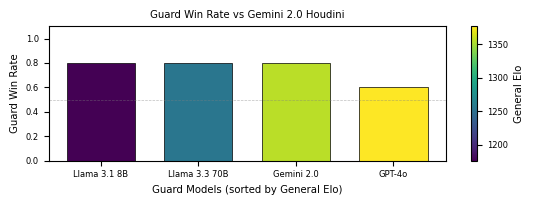

GUARD WIN RATE vs Gemini 2.0 HOUDINI
Llama 3.1 8B    | Gen Elo: 1176 | Win Rate: 0.800
Llama 3.3 70B   | Gen Elo: 1255 | Win Rate: 0.800
Gemini 2.0      | Gen Elo: 1356 | Win Rate: 0.800
GPT-4o          | Gen Elo: 1377 | Win Rate: 0.600


In [22]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load general Elo scores from CSV
llm_elos_df = pd.read_csv('../elo/llm_elos.csv')
llm_elos_dict = dict(zip(llm_elos_df['llm_name'], llm_elos_df['elo']))

# Model name mapping
MODEL_NAME_MAPPING = {
    'google/gemini-2.0-flash-001': 'gemini-2.0-flash-001',
    'meta-llama/llama-3.1-8b-instant': 'llama-3.1-8b-instruct',
    'meta-llama/llama-3.3-70b-instruct': 'llama-3.3-70b-instruct',
    'openai/gpt-4o': 'chatgpt-4o-latest'
}

def clean_model_name(name):
    """Shorten model names for better display"""
    name_map = {
        'google/gemini-2.0-flash-001': 'Gemini 2.0',
        'meta-llama/llama-3.1-8b-instant': 'Llama 3.1 8B',
        'meta-llama/llama-3.3-70b-instruct': 'Llama 3.3 70B',
        'openai/gpt-4o': 'GPT-4o'
    }
    return name_map.get(name, name.split('/')[-1])

def get_general_elo(model_name):
    """Get general Elo for a model from llm_elos.csv"""
    mapped_name = MODEL_NAME_MAPPING.get(model_name, model_name)
    return llm_elos_dict.get(mapped_name, 0)

# Load the win rate data
dataset_path = '../data/win_rates/cnamuangtoun_subset_5_copy.json'

with open(dataset_path) as file:
    data = json.load(file)

df = pd.DataFrame(data)

# Choose which Houdini model to analyze
# Options: 'google/gemini-2.0-flash-001', 'meta-llama/llama-3.1-8b-instant',
#          'meta-llama/llama-3.3-70b-instruct', 'openai/gpt-4o'
FIXED_HOUDINI = 'google/gemini-2.0-flash-001'  # Change this to analyze different Houdinis

# Filter data for the fixed Houdini
houdini_data = df[df['houdini'] == FIXED_HOUDINI]

# Get Guard win rates
guard_win_rates = houdini_data.groupby('guard').agg({
    'guard_win_prob': 'mean'
}).reset_index()
guard_win_rates.columns = ['guard', 'win_rate']

# Get list of Guard models and sort by general Elo
guard_models = guard_win_rates['guard'].tolist()
guard_models_sorted = sorted(guard_models, key=get_general_elo)

# Prepare data for plotting
model_labels = [clean_model_name(m) for m in guard_models_sorted]
win_rates = [guard_win_rates[guard_win_rates['guard'] == m]['win_rate'].values[0]
             for m in guard_models_sorted]
elo_scores = [get_general_elo(m) for m in guard_models_sorted]

# Calculate standard errors (based on variance across games with this Houdini)
guard_stds = houdini_data.groupby('guard')['guard_win_prob'].std().to_dict()
win_rate_errors = [guard_stds.get(m, 0) for m in guard_models_sorted]

# Set up color mapping based on general Elo (same as other charts)
cmap = plt.cm.viridis
norm = plt.Normalize(min(elo_scores), max(elo_scores))
colors = [cmap(norm(elo)) for elo in elo_scores]

# Create the bar chart
with plt.rc_context({
    'font.family': 'sans-serif',
    'font.size': 5,
    'axes.labelsize': 7.25,
    'axes.titlesize': 7.25,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 5.5,
}):
    fig, ax = plt.subplots(1, 1, figsize=(5.5, 2))

    # Bar positions
    positions = np.arange(len(guard_models_sorted))

    # Create bars
    bars = ax.bar(
        positions,
        win_rates,
        width=0.7,
        color=colors,
        edgecolor='black',
        linewidth=0.5
    )

    # Add error bars
    ax.errorbar(
        positions,
        win_rates,
        yerr=win_rate_errors,
        fmt='none',
        ecolor='#AAAAAA',
        capsize=2,
        elinewidth=1,
        capthick=0.5,
    )

    # Customize axes
    ax.set_xticks(positions)
    ax.set_xticklabels(model_labels, rotation=0)
    ax.set_ylabel('Guard Win Rate')
    ax.set_xlabel('Guard Models (sorted by General Elo)')
    ax.set_title(f'Guard Win Rate vs {clean_model_name(FIXED_HOUDINI)} Houdini')

    # Set y-axis limits
    ax.set_ylim(0, 1.1)
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    # Add colorbar to show General Elo mapping
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('General Elo')

    plt.tight_layout()


    plt.show()

# Print statistics
print("="*60)
print(f"GUARD WIN RATE vs {clean_model_name(FIXED_HOUDINI)} HOUDINI")
print("="*60)
for model, label, elo, win_rate in zip(guard_models_sorted, model_labels,
                                       elo_scores, win_rates):
    print(f"{label:15s} | Gen Elo: {elo:4d} | Win Rate: {win_rate:.3f}")

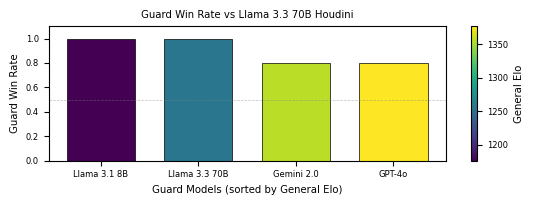

GUARD WIN RATE vs Llama 3.3 70B HOUDINI
Llama 3.1 8B    | Gen Elo: 1176 | Win Rate: 1.000
Llama 3.3 70B   | Gen Elo: 1255 | Win Rate: 1.000
Gemini 2.0      | Gen Elo: 1356 | Win Rate: 0.800
GPT-4o          | Gen Elo: 1377 | Win Rate: 0.800


In [23]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load general Elo scores from CSV
llm_elos_df = pd.read_csv('../elo/llm_elos.csv')
llm_elos_dict = dict(zip(llm_elos_df['llm_name'], llm_elos_df['elo']))

# Model name mapping
MODEL_NAME_MAPPING = {
    'google/gemini-2.0-flash-001': 'gemini-2.0-flash-001',
    'meta-llama/llama-3.1-8b-instant': 'llama-3.1-8b-instruct',
    'meta-llama/llama-3.3-70b-instruct': 'llama-3.3-70b-instruct',
    'openai/gpt-4o': 'chatgpt-4o-latest'
}

def clean_model_name(name):
    """Shorten model names for better display"""
    name_map = {
        'google/gemini-2.0-flash-001': 'Gemini 2.0',
        'meta-llama/llama-3.1-8b-instant': 'Llama 3.1 8B',
        'meta-llama/llama-3.3-70b-instruct': 'Llama 3.3 70B',
        'openai/gpt-4o': 'GPT-4o'
    }
    return name_map.get(name, name.split('/')[-1])

def get_general_elo(model_name):
    """Get general Elo for a model from llm_elos.csv"""
    mapped_name = MODEL_NAME_MAPPING.get(model_name, model_name)
    return llm_elos_dict.get(mapped_name, 0)

# Load the win rate data
dataset_path = '../data/win_rates/cnamuangtoun_subset_5_copy.json'

with open(dataset_path) as file:
    data = json.load(file)

df = pd.DataFrame(data)

# Choose which Houdini model to analyze
# Options: 'google/gemini-2.0-flash-001', 'meta-llama/llama-3.1-8b-instant',
#          'meta-llama/llama-3.3-70b-instruct', 'openai/gpt-4o'
FIXED_HOUDINI = 'meta-llama/llama-3.3-70b-instruct'  # Change this to analyze different Houdinis

# Filter data for the fixed Houdini
houdini_data = df[df['houdini'] == FIXED_HOUDINI]

# Get Guard win rates
guard_win_rates = houdini_data.groupby('guard').agg({
    'guard_win_prob': 'mean'
}).reset_index()
guard_win_rates.columns = ['guard', 'win_rate']

# Get list of Guard models and sort by general Elo
guard_models = guard_win_rates['guard'].tolist()
guard_models_sorted = sorted(guard_models, key=get_general_elo)

# Prepare data for plotting
model_labels = [clean_model_name(m) for m in guard_models_sorted]
win_rates = [guard_win_rates[guard_win_rates['guard'] == m]['win_rate'].values[0]
             for m in guard_models_sorted]
elo_scores = [get_general_elo(m) for m in guard_models_sorted]

# Calculate standard errors (based on variance across games with this Houdini)
guard_stds = houdini_data.groupby('guard')['guard_win_prob'].std().to_dict()
win_rate_errors = [guard_stds.get(m, 0) for m in guard_models_sorted]

# Set up color mapping based on general Elo (same as other charts)
cmap = plt.cm.viridis
norm = plt.Normalize(min(elo_scores), max(elo_scores))
colors = [cmap(norm(elo)) for elo in elo_scores]

# Create the bar chart
with plt.rc_context({
    'font.family': 'sans-serif',
    'font.size': 5,
    'axes.labelsize': 7.25,
    'axes.titlesize': 7.25,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 5.5,
}):
    fig, ax = plt.subplots(1, 1, figsize=(5.5, 2))

    # Bar positions
    positions = np.arange(len(guard_models_sorted))

    # Create bars
    bars = ax.bar(
        positions,
        win_rates,
        width=0.7,
        color=colors,
        edgecolor='black',
        linewidth=0.5
    )

    # Add error bars
    ax.errorbar(
        positions,
        win_rates,
        yerr=win_rate_errors,
        fmt='none',
        ecolor='#AAAAAA',
        capsize=2,
        elinewidth=1,
        capthick=0.5,
    )

    # Customize axes
    ax.set_xticks(positions)
    ax.set_xticklabels(model_labels, rotation=0)
    ax.set_ylabel('Guard Win Rate')
    ax.set_xlabel('Guard Models (sorted by General Elo)')
    ax.set_title(f'Guard Win Rate vs {clean_model_name(FIXED_HOUDINI)} Houdini')

    # Set y-axis limits
    ax.set_ylim(0, 1.1)
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    # Add colorbar to show General Elo mapping
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('General Elo')

    plt.tight_layout()


    plt.show()

# Print statistics
print("="*60)
print(f"GUARD WIN RATE vs {clean_model_name(FIXED_HOUDINI)} HOUDINI")
print("="*60)
for model, label, elo, win_rate in zip(guard_models_sorted, model_labels,
                                       elo_scores, win_rates):
    print(f"{label:15s} | Gen Elo: {elo:4d} | Win Rate: {win_rate:.3f}")

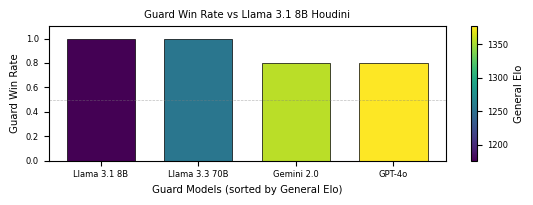

GUARD WIN RATE vs Llama 3.1 8B HOUDINI
Llama 3.1 8B    | Gen Elo: 1176 | Win Rate: 1.000
Llama 3.3 70B   | Gen Elo: 1255 | Win Rate: 1.000
Gemini 2.0      | Gen Elo: 1356 | Win Rate: 0.800
GPT-4o          | Gen Elo: 1377 | Win Rate: 0.800


In [24]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load general Elo scores from CSV
llm_elos_df = pd.read_csv('../elo/llm_elos.csv')
llm_elos_dict = dict(zip(llm_elos_df['llm_name'], llm_elos_df['elo']))

# Model name mapping
MODEL_NAME_MAPPING = {
    'google/gemini-2.0-flash-001': 'gemini-2.0-flash-001',
    'meta-llama/llama-3.1-8b-instant': 'llama-3.1-8b-instruct',
    'meta-llama/llama-3.3-70b-instruct': 'llama-3.3-70b-instruct',
    'openai/gpt-4o': 'chatgpt-4o-latest'
}

def clean_model_name(name):
    """Shorten model names for better display"""
    name_map = {
        'google/gemini-2.0-flash-001': 'Gemini 2.0',
        'meta-llama/llama-3.1-8b-instant': 'Llama 3.1 8B',
        'meta-llama/llama-3.3-70b-instruct': 'Llama 3.3 70B',
        'openai/gpt-4o': 'GPT-4o'
    }
    return name_map.get(name, name.split('/')[-1])

def get_general_elo(model_name):
    """Get general Elo for a model from llm_elos.csv"""
    mapped_name = MODEL_NAME_MAPPING.get(model_name, model_name)
    return llm_elos_dict.get(mapped_name, 0)

# Load the win rate data
dataset_path = '../data/win_rates/cnamuangtoun_subset_5_copy.json'

with open(dataset_path) as file:
    data = json.load(file)

df = pd.DataFrame(data)

# Choose which Houdini model to analyze
# Options: 'google/gemini-2.0-flash-001', 'meta-llama/llama-3.1-8b-instant',
#          'meta-llama/llama-3.3-70b-instruct', 'openai/gpt-4o'
FIXED_HOUDINI = 'meta-llama/llama-3.1-8b-instant'  # Change this to analyze different Houdinis

# Filter data for the fixed Houdini
houdini_data = df[df['houdini'] == FIXED_HOUDINI]

# Get Guard win rates
guard_win_rates = houdini_data.groupby('guard').agg({
    'guard_win_prob': 'mean'
}).reset_index()
guard_win_rates.columns = ['guard', 'win_rate']

# Get list of Guard models and sort by general Elo
guard_models = guard_win_rates['guard'].tolist()
guard_models_sorted = sorted(guard_models, key=get_general_elo)

# Prepare data for plotting
model_labels = [clean_model_name(m) for m in guard_models_sorted]
win_rates = [guard_win_rates[guard_win_rates['guard'] == m]['win_rate'].values[0]
             for m in guard_models_sorted]
elo_scores = [get_general_elo(m) for m in guard_models_sorted]

# Calculate standard errors (based on variance across games with this Houdini)
guard_stds = houdini_data.groupby('guard')['guard_win_prob'].std().to_dict()
win_rate_errors = [guard_stds.get(m, 0) for m in guard_models_sorted]

# Set up color mapping based on general Elo (same as other charts)
cmap = plt.cm.viridis
norm = plt.Normalize(min(elo_scores), max(elo_scores))
colors = [cmap(norm(elo)) for elo in elo_scores]

# Create the bar chart
with plt.rc_context({
    'font.family': 'sans-serif',
    'font.size': 5,
    'axes.labelsize': 7.25,
    'axes.titlesize': 7.25,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 5.5,
}):
    fig, ax = plt.subplots(1, 1, figsize=(5.5, 2))

    # Bar positions
    positions = np.arange(len(guard_models_sorted))

    # Create bars
    bars = ax.bar(
        positions,
        win_rates,
        width=0.7,
        color=colors,
        edgecolor='black',
        linewidth=0.5
    )

    # Add error bars
    ax.errorbar(
        positions,
        win_rates,
        yerr=win_rate_errors,
        fmt='none',
        ecolor='#AAAAAA',
        capsize=2,
        elinewidth=1,
        capthick=0.5,
    )

    # Customize axes
    ax.set_xticks(positions)
    ax.set_xticklabels(model_labels, rotation=0)
    ax.set_ylabel('Guard Win Rate')
    ax.set_xlabel('Guard Models (sorted by General Elo)')
    ax.set_title(f'Guard Win Rate vs {clean_model_name(FIXED_HOUDINI)} Houdini')

    # Set y-axis limits
    ax.set_ylim(0, 1.1)
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    # Add colorbar to show General Elo mapping
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('General Elo')

    plt.tight_layout()


    plt.show()

# Print statistics
print("="*60)
print(f"GUARD WIN RATE vs {clean_model_name(FIXED_HOUDINI)} HOUDINI")
print("="*60)
for model, label, elo, win_rate in zip(guard_models_sorted, model_labels,
                                       elo_scores, win_rates):
    print(f"{label:15s} | Gen Elo: {elo:4d} | Win Rate: {win_rate:.3f}")

# Success Rate with fixed guard model

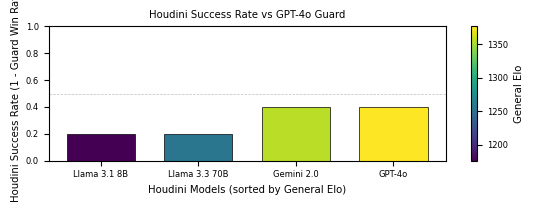

HOUDINI SUCCESS RATE vs GPT-4o GUARD
Llama 3.1 8B    | Gen Elo: 1176 | Success Rate: 0.200
Llama 3.3 70B   | Gen Elo: 1255 | Success Rate: 0.200
Gemini 2.0      | Gen Elo: 1356 | Success Rate: 0.400
GPT-4o          | Gen Elo: 1377 | Success Rate: 0.400


In [14]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load general Elo scores from CSV
llm_elos_df = pd.read_csv('../elo/llm_elos.csv')
llm_elos_dict = dict(zip(llm_elos_df['llm_name'], llm_elos_df['elo']))

# Model name mapping
MODEL_NAME_MAPPING = {
    'google/gemini-2.0-flash-001': 'gemini-2.0-flash-001',
    'meta-llama/llama-3.1-8b-instant': 'llama-3.1-8b-instruct',
    'meta-llama/llama-3.3-70b-instruct': 'llama-3.3-70b-instruct',
    'openai/gpt-4o': 'chatgpt-4o-latest'
}

def clean_model_name(name):
    """Shorten model names for better display"""
    name_map = {
        'google/gemini-2.0-flash-001': 'Gemini 2.0',
        'meta-llama/llama-3.1-8b-instant': 'Llama 3.1 8B',
        'meta-llama/llama-3.3-70b-instruct': 'Llama 3.3 70B',
        'openai/gpt-4o': 'GPT-4o'
    }
    return name_map.get(name, name.split('/')[-1])

def get_general_elo(model_name):
    """Get general Elo for a model from llm_elos.csv"""
    mapped_name = MODEL_NAME_MAPPING.get(model_name, model_name)
    return llm_elos_dict.get(mapped_name, 0)

# Load the win rate data
dataset_path = '../data/win_rates/cnamuangtoun_subset_5_copy.json'

with open(dataset_path) as file:
    data = json.load(file)

df = pd.DataFrame(data)

# Choose which guard model to analyze
# Options: 'google/gemini-2.0-flash-001', 'meta-llama/llama-3.1-8b-instant',
#          'meta-llama/llama-3.3-70b-instruct', 'openai/gpt-4o'
FIXED_GUARD = 'openai/gpt-4o'  # Change this to analyze different guards

# Filter data for the fixed guard
guard_data = df[df['guard'] == FIXED_GUARD]

# Get Houdini success rates (1 - guard_win_prob)
houdini_success = guard_data.groupby('houdini').agg({
    'guard_win_prob': lambda x: 1 - x.mean()  # Success rate = 1 - guard win rate
}).reset_index()
houdini_success.columns = ['houdini', 'success_rate']

# Get list of Houdini models and sort by general Elo
houdini_models = houdini_success['houdini'].tolist()
houdini_models_sorted = sorted(houdini_models, key=get_general_elo)

# Prepare data for plotting
model_labels = [clean_model_name(m) for m in houdini_models_sorted]
success_rates = [houdini_success[houdini_success['houdini'] == m]['success_rate'].values[0]
                 for m in houdini_models_sorted]
elo_scores = [get_general_elo(m) for m in houdini_models_sorted]

# Calculate standard errors (based on variance across games with this guard)
houdini_stds = guard_data.groupby('houdini')['guard_win_prob'].std().to_dict()
success_rate_errors = [houdini_stds.get(m, 0) for m in houdini_models_sorted]

# Set up color mapping based on general Elo
cmap = plt.cm.viridis  # Using viridis to match Guard chart
norm = plt.Normalize(min(elo_scores), max(elo_scores))
colors = [cmap(norm(elo)) for elo in elo_scores]

# Create the bar chart
with plt.rc_context({
    'font.family': 'sans-serif',
    'font.size': 5,
    'axes.labelsize': 7.25,
    'axes.titlesize': 7.25,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 5.5,
}):
    fig, ax = plt.subplots(1, 1, figsize=(5.5, 2))

    # Bar positions
    positions = np.arange(len(houdini_models_sorted))

    # Create bars
    bars = ax.bar(
        positions,
        success_rates,
        width=0.7,
        color=colors,
        edgecolor='black',
        linewidth=0.5
    )

    # Add error bars
    ax.errorbar(
        positions,
        success_rates,
        yerr=success_rate_errors,
        fmt='none',
        ecolor='#AAAAAA',
        capsize=2,
        elinewidth=1,
        capthick=0.5,
    )

    # Customize axes
    ax.set_xticks(positions)
    ax.set_xticklabels(model_labels, rotation=0)
    ax.set_ylabel('Houdini Success Rate (1 - Guard Win Rate)')
    ax.set_xlabel('Houdini Models (sorted by General Elo)')
    ax.set_title(f'Houdini Success Rate vs {clean_model_name(FIXED_GUARD)} Guard')

    # Set y-axis limits
    ax.set_ylim(0, 1)
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    # Add colorbar to show General Elo mapping
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('General Elo')

    plt.tight_layout()


    plt.show()

# Print statistics
print("="*60)
print(f"HOUDINI SUCCESS RATE vs {clean_model_name(FIXED_GUARD)} GUARD")
print("="*60)
for model, label, elo, success_rate in zip(houdini_models_sorted, model_labels,
                                            elo_scores, success_rates):
    print(f"{label:15s} | Gen Elo: {elo:4d} | Success Rate: {success_rate:.3f}")

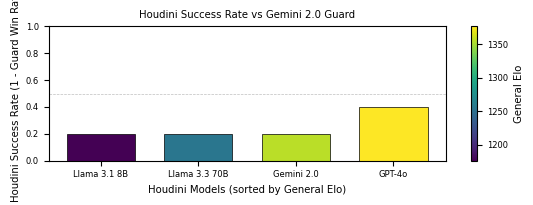

HOUDINI SUCCESS RATE vs Gemini 2.0 GUARD
Llama 3.1 8B    | Gen Elo: 1176 | Success Rate: 0.200
Llama 3.3 70B   | Gen Elo: 1255 | Success Rate: 0.200
Gemini 2.0      | Gen Elo: 1356 | Success Rate: 0.200
GPT-4o          | Gen Elo: 1377 | Success Rate: 0.400


In [17]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load general Elo scores from CSV
llm_elos_df = pd.read_csv('../elo/llm_elos.csv')
llm_elos_dict = dict(zip(llm_elos_df['llm_name'], llm_elos_df['elo']))

# Model name mapping
MODEL_NAME_MAPPING = {
    'google/gemini-2.0-flash-001': 'gemini-2.0-flash-001',
    'meta-llama/llama-3.1-8b-instant': 'llama-3.1-8b-instruct',
    'meta-llama/llama-3.3-70b-instruct': 'llama-3.3-70b-instruct',
    'openai/gpt-4o': 'chatgpt-4o-latest'
}

def clean_model_name(name):
    """Shorten model names for better display"""
    name_map = {
        'google/gemini-2.0-flash-001': 'Gemini 2.0',
        'meta-llama/llama-3.1-8b-instant': 'Llama 3.1 8B',
        'meta-llama/llama-3.3-70b-instruct': 'Llama 3.3 70B',
        'openai/gpt-4o': 'GPT-4o'
    }
    return name_map.get(name, name.split('/')[-1])

def get_general_elo(model_name):
    """Get general Elo for a model from llm_elos.csv"""
    mapped_name = MODEL_NAME_MAPPING.get(model_name, model_name)
    return llm_elos_dict.get(mapped_name, 0)

# Load the win rate data
dataset_path = '../data/win_rates/cnamuangtoun_subset_5_copy.json'

with open(dataset_path) as file:
    data = json.load(file)

df = pd.DataFrame(data)

# Choose which guard model to analyze
# Options: 'google/gemini-2.0-flash-001', 'meta-llama/llama-3.1-8b-instant',
#          'meta-llama/llama-3.3-70b-instruct', 'openai/gpt-4o'
FIXED_GUARD = 'google/gemini-2.0-flash-001'  # Change this to analyze different guards

# Filter data for the fixed guard
guard_data = df[df['guard'] == FIXED_GUARD]

# Get Houdini success rates (1 - guard_win_prob)
houdini_success = guard_data.groupby('houdini').agg({
    'guard_win_prob': lambda x: 1 - x.mean()  # Success rate = 1 - guard win rate
}).reset_index()
houdini_success.columns = ['houdini', 'success_rate']

# Get list of Houdini models and sort by general Elo
houdini_models = houdini_success['houdini'].tolist()
houdini_models_sorted = sorted(houdini_models, key=get_general_elo)

# Prepare data for plotting
model_labels = [clean_model_name(m) for m in houdini_models_sorted]
success_rates = [houdini_success[houdini_success['houdini'] == m]['success_rate'].values[0]
                 for m in houdini_models_sorted]
elo_scores = [get_general_elo(m) for m in houdini_models_sorted]

# Calculate standard errors (based on variance across games with this guard)
houdini_stds = guard_data.groupby('houdini')['guard_win_prob'].std().to_dict()
success_rate_errors = [houdini_stds.get(m, 0) for m in houdini_models_sorted]

# Set up color mapping based on general Elo
cmap = plt.cm.viridis  # Using viridis to match Guard chart
norm = plt.Normalize(min(elo_scores), max(elo_scores))
colors = [cmap(norm(elo)) for elo in elo_scores]

# Create the bar chart
with plt.rc_context({
    'font.family': 'sans-serif',
    'font.size': 5,
    'axes.labelsize': 7.25,
    'axes.titlesize': 7.25,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 5.5,
}):
    fig, ax = plt.subplots(1, 1, figsize=(5.5, 2))

    # Bar positions
    positions = np.arange(len(houdini_models_sorted))

    # Create bars
    bars = ax.bar(
        positions,
        success_rates,
        width=0.7,
        color=colors,
        edgecolor='black',
        linewidth=0.5
    )

    # Add error bars
    ax.errorbar(
        positions,
        success_rates,
        yerr=success_rate_errors,
        fmt='none',
        ecolor='#AAAAAA',
        capsize=2,
        elinewidth=1,
        capthick=0.5,
    )

    # Customize axes
    ax.set_xticks(positions)
    ax.set_xticklabels(model_labels, rotation=0)
    ax.set_ylabel('Houdini Success Rate (1 - Guard Win Rate)')
    ax.set_xlabel('Houdini Models (sorted by General Elo)')
    ax.set_title(f'Houdini Success Rate vs {clean_model_name(FIXED_GUARD)} Guard')

    # Set y-axis limits
    ax.set_ylim(0, 1)
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    # Add colorbar to show General Elo mapping
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('General Elo')

    plt.tight_layout()


    plt.show()

# Print statistics
print("="*60)
print(f"HOUDINI SUCCESS RATE vs {clean_model_name(FIXED_GUARD)} GUARD")
print("="*60)
for model, label, elo, success_rate in zip(houdini_models_sorted, model_labels,
                                            elo_scores, success_rates):
    print(f"{label:15s} | Gen Elo: {elo:4d} | Success Rate: {success_rate:.3f}")

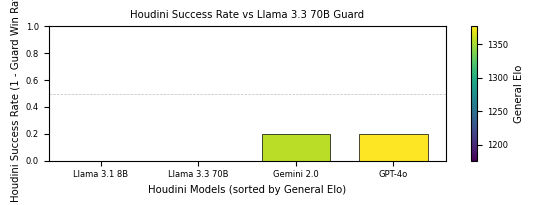

HOUDINI SUCCESS RATE vs Llama 3.3 70B GUARD
Llama 3.1 8B    | Gen Elo: 1176 | Success Rate: 0.000
Llama 3.3 70B   | Gen Elo: 1255 | Success Rate: 0.000
Gemini 2.0      | Gen Elo: 1356 | Success Rate: 0.200
GPT-4o          | Gen Elo: 1377 | Success Rate: 0.200


In [28]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load general Elo scores from CSV
llm_elos_df = pd.read_csv('../elo/llm_elos.csv')
llm_elos_dict = dict(zip(llm_elos_df['llm_name'], llm_elos_df['elo']))

# Model name mapping
MODEL_NAME_MAPPING = {
    'google/gemini-2.0-flash-001': 'gemini-2.0-flash-001',
    'meta-llama/llama-3.1-8b-instant': 'llama-3.1-8b-instruct',
    'meta-llama/llama-3.3-70b-instruct': 'llama-3.3-70b-instruct',
    'openai/gpt-4o': 'chatgpt-4o-latest'
}

def clean_model_name(name):
    """Shorten model names for better display"""
    name_map = {
        'google/gemini-2.0-flash-001': 'Gemini 2.0',
        'meta-llama/llama-3.1-8b-instant': 'Llama 3.1 8B',
        'meta-llama/llama-3.3-70b-instruct': 'Llama 3.3 70B',
        'openai/gpt-4o': 'GPT-4o'
    }
    return name_map.get(name, name.split('/')[-1])

def get_general_elo(model_name):
    """Get general Elo for a model from llm_elos.csv"""
    mapped_name = MODEL_NAME_MAPPING.get(model_name, model_name)
    return llm_elos_dict.get(mapped_name, 0)

# Load the win rate data
dataset_path = '../data/win_rates/cnamuangtoun_subset_5_copy.json'

with open(dataset_path) as file:
    data = json.load(file)

df = pd.DataFrame(data)

# Choose which guard model to analyze
# Options: 'google/gemini-2.0-flash-001', 'meta-llama/llama-3.1-8b-instant',
#          'meta-llama/llama-3.3-70b-instruct', 'openai/gpt-4o'
FIXED_GUARD = 'meta-llama/llama-3.3-70b-instruct'  # Change this to analyze different guards

# Filter data for the fixed guard
guard_data = df[df['guard'] == FIXED_GUARD]

# Get Houdini success rates (1 - guard_win_prob)
houdini_success = guard_data.groupby('houdini').agg({
    'guard_win_prob': lambda x: 1 - x.mean()  # Success rate = 1 - guard win rate
}).reset_index()
houdini_success.columns = ['houdini', 'success_rate']

# Get list of Houdini models and sort by general Elo
houdini_models = houdini_success['houdini'].tolist()
houdini_models_sorted = sorted(houdini_models, key=get_general_elo)

# Prepare data for plotting
model_labels = [clean_model_name(m) for m in houdini_models_sorted]
success_rates = [houdini_success[houdini_success['houdini'] == m]['success_rate'].values[0]
                 for m in houdini_models_sorted]
elo_scores = [get_general_elo(m) for m in houdini_models_sorted]

# Calculate standard errors (based on variance across games with this guard)
houdini_stds = guard_data.groupby('houdini')['guard_win_prob'].std().to_dict()
success_rate_errors = [houdini_stds.get(m, 0) for m in houdini_models_sorted]

# Set up color mapping based on general Elo
cmap = plt.cm.viridis  # Using viridis to match Guard chart
norm = plt.Normalize(min(elo_scores), max(elo_scores))
colors = [cmap(norm(elo)) for elo in elo_scores]

# Create the bar chart
with plt.rc_context({
    'font.family': 'sans-serif',
    'font.size': 5,
    'axes.labelsize': 7.25,
    'axes.titlesize': 7.25,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 5.5,
}):
    fig, ax = plt.subplots(1, 1, figsize=(5.5, 2))

    # Bar positions
    positions = np.arange(len(houdini_models_sorted))

    # Create bars
    bars = ax.bar(
        positions,
        success_rates,
        width=0.7,
        color=colors,
        edgecolor='black',
        linewidth=0.5
    )

    # Add error bars
    ax.errorbar(
        positions,
        success_rates,
        yerr=success_rate_errors,
        fmt='none',
        ecolor='#AAAAAA',
        capsize=2,
        elinewidth=1,
        capthick=0.5,
    )

    # Customize axes
    ax.set_xticks(positions)
    ax.set_xticklabels(model_labels, rotation=0)
    ax.set_ylabel('Houdini Success Rate (1 - Guard Win Rate)')
    ax.set_xlabel('Houdini Models (sorted by General Elo)')
    ax.set_title(f'Houdini Success Rate vs {clean_model_name(FIXED_GUARD)} Guard')

    # Set y-axis limits
    ax.set_ylim(0, 1)
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    # Add colorbar to show General Elo mapping
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('General Elo')

    plt.tight_layout()


    plt.show()

# Print statistics
print("="*60)
print(f"HOUDINI SUCCESS RATE vs {clean_model_name(FIXED_GUARD)} GUARD")
print("="*60)
for model, label, elo, success_rate in zip(houdini_models_sorted, model_labels,
                                            elo_scores, success_rates):
    print(f"{label:15s} | Gen Elo: {elo:4d} | Success Rate: {success_rate:.3f}")

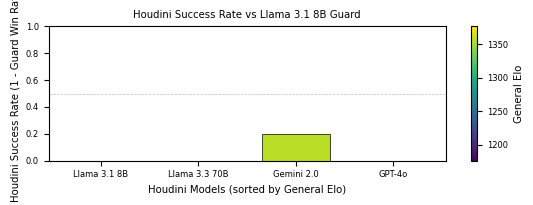

HOUDINI SUCCESS RATE vs Llama 3.1 8B GUARD
Llama 3.1 8B    | Gen Elo: 1176 | Success Rate: 0.000
Llama 3.3 70B   | Gen Elo: 1255 | Success Rate: 0.000
Gemini 2.0      | Gen Elo: 1356 | Success Rate: 0.200
GPT-4o          | Gen Elo: 1377 | Success Rate: 0.000


In [29]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load general Elo scores from CSV
llm_elos_df = pd.read_csv('../elo/llm_elos.csv')
llm_elos_dict = dict(zip(llm_elos_df['llm_name'], llm_elos_df['elo']))

# Model name mapping
MODEL_NAME_MAPPING = {
    'google/gemini-2.0-flash-001': 'gemini-2.0-flash-001',
    'meta-llama/llama-3.1-8b-instant': 'llama-3.1-8b-instruct',
    'meta-llama/llama-3.3-70b-instruct': 'llama-3.3-70b-instruct',
    'openai/gpt-4o': 'chatgpt-4o-latest'
}

def clean_model_name(name):
    """Shorten model names for better display"""
    name_map = {
        'google/gemini-2.0-flash-001': 'Gemini 2.0',
        'meta-llama/llama-3.1-8b-instant': 'Llama 3.1 8B',
        'meta-llama/llama-3.3-70b-instruct': 'Llama 3.3 70B',
        'openai/gpt-4o': 'GPT-4o'
    }
    return name_map.get(name, name.split('/')[-1])

def get_general_elo(model_name):
    """Get general Elo for a model from llm_elos.csv"""
    mapped_name = MODEL_NAME_MAPPING.get(model_name, model_name)
    return llm_elos_dict.get(mapped_name, 0)

# Load the win rate data
dataset_path = '../data/win_rates/cnamuangtoun_subset_5_copy.json'

with open(dataset_path) as file:
    data = json.load(file)

df = pd.DataFrame(data)

# Choose which guard model to analyze
# Options: 'google/gemini-2.0-flash-001', 'meta-llama/llama-3.1-8b-instant',
#          'meta-llama/llama-3.3-70b-instruct', 'openai/gpt-4o'
FIXED_GUARD = 'meta-llama/llama-3.1-8b-instant'  # Change this to analyze different guards

# Filter data for the fixed guard
guard_data = df[df['guard'] == FIXED_GUARD]

# Get Houdini success rates (1 - guard_win_prob)
houdini_success = guard_data.groupby('houdini').agg({
    'guard_win_prob': lambda x: 1 - x.mean()  # Success rate = 1 - guard win rate
}).reset_index()
houdini_success.columns = ['houdini', 'success_rate']

# Get list of Houdini models and sort by general Elo
houdini_models = houdini_success['houdini'].tolist()
houdini_models_sorted = sorted(houdini_models, key=get_general_elo)

# Prepare data for plotting
model_labels = [clean_model_name(m) for m in houdini_models_sorted]
success_rates = [houdini_success[houdini_success['houdini'] == m]['success_rate'].values[0]
                 for m in houdini_models_sorted]
elo_scores = [get_general_elo(m) for m in houdini_models_sorted]

# Calculate standard errors (based on variance across games with this guard)
houdini_stds = guard_data.groupby('houdini')['guard_win_prob'].std().to_dict()
success_rate_errors = [houdini_stds.get(m, 0) for m in houdini_models_sorted]

# Set up color mapping based on general Elo
cmap = plt.cm.viridis  # Using viridis to match Guard chart
norm = plt.Normalize(min(elo_scores), max(elo_scores))
colors = [cmap(norm(elo)) for elo in elo_scores]

# Create the bar chart
with plt.rc_context({
    'font.family': 'sans-serif',
    'font.size': 5,
    'axes.labelsize': 7.25,
    'axes.titlesize': 7.25,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
    'legend.fontsize': 5.5,
}):
    fig, ax = plt.subplots(1, 1, figsize=(5.5, 2))

    # Bar positions
    positions = np.arange(len(houdini_models_sorted))

    # Create bars
    bars = ax.bar(
        positions,
        success_rates,
        width=0.7,
        color=colors,
        edgecolor='black',
        linewidth=0.5
    )

    # Add error bars
    ax.errorbar(
        positions,
        success_rates,
        yerr=success_rate_errors,
        fmt='none',
        ecolor='#AAAAAA',
        capsize=2,
        elinewidth=1,
        capthick=0.5,
    )

    # Customize axes
    ax.set_xticks(positions)
    ax.set_xticklabels(model_labels, rotation=0)
    ax.set_ylabel('Houdini Success Rate (1 - Guard Win Rate)')
    ax.set_xlabel('Houdini Models (sorted by General Elo)')
    ax.set_title(f'Houdini Success Rate vs {clean_model_name(FIXED_GUARD)} Guard')

    # Set y-axis limits
    ax.set_ylim(0, 1)
    ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)

    # Add colorbar to show General Elo mapping
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=ax)
    cbar.set_label('General Elo')

    plt.tight_layout()


    plt.show()

# Print statistics
print("="*60)
print(f"HOUDINI SUCCESS RATE vs {clean_model_name(FIXED_GUARD)} GUARD")
print("="*60)
for model, label, elo, success_rate in zip(houdini_models_sorted, model_labels,
                                            elo_scores, success_rates):
    print(f"{label:15s} | Gen Elo: {elo:4d} | Success Rate: {success_rate:.3f}")

/tmp/ipython-input-4068997340.py:127: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.92, 1])


Combined figure saved successfully!

Rows (top to bottom):
  1. GPT-4o (Elo 1377)
  2. Gemini 2.0 (Elo 1356)
  3. Llama 3.3 70B (Elo 1255)
  4. Llama 3.1 8B (Elo 1176)

Columns:
  Left: Guard win rate (fixed model as Houdini)
  Right: Houdini success rate (fixed model as Guard)


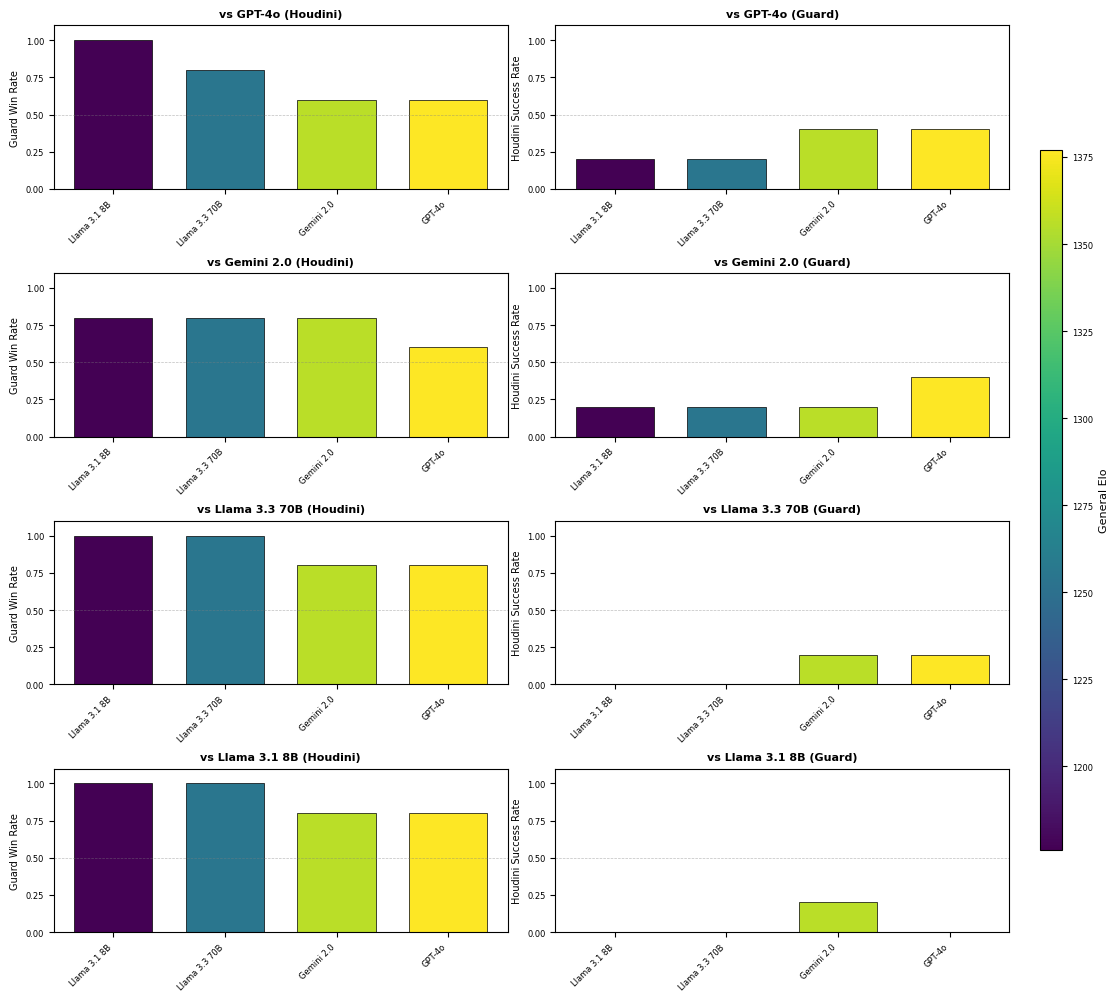

In [27]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load general Elo scores from CSV
llm_elos_df = pd.read_csv('../elo/llm_elos.csv')
llm_elos_dict = dict(zip(llm_elos_df['llm_name'], llm_elos_df['elo']))

# Model name mapping
MODEL_NAME_MAPPING = {
    'google/gemini-2.0-flash-001': 'gemini-2.0-flash-001',
    'meta-llama/llama-3.1-8b-instant': 'llama-3.1-8b-instruct',
    'meta-llama/llama-3.3-70b-instruct': 'llama-3.3-70b-instruct',
    'openai/gpt-4o': 'chatgpt-4o-latest'
}

def clean_model_name(name):
    """Shorten model names for better display"""
    name_map = {
        'google/gemini-2.0-flash-001': 'Gemini 2.0',
        'meta-llama/llama-3.1-8b-instant': 'Llama 3.1 8B',
        'meta-llama/llama-3.3-70b-instruct': 'Llama 3.3 70B',
        'openai/gpt-4o': 'GPT-4o'
    }
    return name_map.get(name, name.split('/')[-1])

def get_general_elo(model_name):
    """Get general Elo for a model from llm_elos.csv"""
    mapped_name = MODEL_NAME_MAPPING.get(model_name, model_name)
    return llm_elos_dict.get(mapped_name, 0)

# Load the win rate data
dataset_path = '../data/win_rates/cnamuangtoun_subset_5_copy.json'

with open(dataset_path) as file:
    data = json.load(file)

df = pd.DataFrame(data)

# Define the order of models (sorted by Elo, descending)
all_models = df['guard'].unique().tolist()
models_sorted = sorted(all_models, key=get_general_elo, reverse=True)

# Models in order: GPT-4o, Gemini 2.0, Llama 3.3 70B, Llama 3.1 8B
fixed_models = models_sorted

# Set up color mapping
all_elo_scores = [get_general_elo(m) for m in all_models]
cmap = plt.cm.viridis
norm = plt.Normalize(min(all_elo_scores), max(all_elo_scores))

# Create figure with 4 rows x 2 columns
with plt.rc_context({
    'font.family': 'sans-serif',
    'font.size': 6,
    'axes.labelsize': 7,
    'axes.titlesize': 8,
    'xtick.labelsize': 6,
    'ytick.labelsize': 6,
}):
    fig, axes = plt.subplots(4, 2, figsize=(11, 10))

    for row_idx, fixed_model in enumerate(fixed_models):
        # Left column: Guard win rate (fixed Houdini)
        ax_left = axes[row_idx, 0]

        # Filter data where fixed_model is Houdini
        houdini_data = df[df['houdini'] == fixed_model]
        guard_models = sorted(houdini_data['guard'].unique().tolist(), key=get_general_elo)

        guard_win_rates = [houdini_data[houdini_data['guard'] == g]['guard_win_prob'].mean()
                          for g in guard_models]
        guard_stds = [houdini_data[houdini_data['guard'] == g]['guard_win_prob'].std()
                     for g in guard_models]
        guard_elos = [get_general_elo(g) for g in guard_models]
        guard_colors = [cmap(norm(elo)) for elo in guard_elos]

        positions = np.arange(len(guard_models))
        ax_left.bar(positions, guard_win_rates, width=0.7, color=guard_colors,
                   edgecolor='black', linewidth=0.5)
        ax_left.errorbar(positions, guard_win_rates, yerr=guard_stds, fmt='none',
                        ecolor='#AAAAAA', capsize=2, elinewidth=1, capthick=0.5)

        ax_left.set_xticks(positions)
        ax_left.set_xticklabels([clean_model_name(g) for g in guard_models], rotation=45, ha='right')
        ax_left.set_ylim(0, 1.1)
        ax_left.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
        ax_left.set_ylabel('Guard Win Rate')
        ax_left.set_title(f'vs {clean_model_name(fixed_model)} (Houdini)', fontweight='bold')

        # Right column: Houdini success rate (fixed Guard)
        ax_right = axes[row_idx, 1]

        # Filter data where fixed_model is Guard
        guard_data = df[df['guard'] == fixed_model]
        houdini_models = sorted(guard_data['houdini'].unique().tolist(), key=get_general_elo)

        houdini_success_rates = [1 - guard_data[guard_data['houdini'] == h]['guard_win_prob'].mean()
                                for h in houdini_models]
        houdini_stds = [guard_data[guard_data['houdini'] == h]['guard_win_prob'].std()
                       for h in houdini_models]
        houdini_elos = [get_general_elo(h) for h in houdini_models]
        houdini_colors = [cmap(norm(elo)) for elo in houdini_elos]

        positions = np.arange(len(houdini_models))
        ax_right.bar(positions, houdini_success_rates, width=0.7, color=houdini_colors,
                    edgecolor='black', linewidth=0.5)
        ax_right.errorbar(positions, houdini_success_rates, yerr=houdini_stds, fmt='none',
                         ecolor='#AAAAAA', capsize=2, elinewidth=1, capthick=0.5)

        ax_right.set_xticks(positions)
        ax_right.set_xticklabels([clean_model_name(h) for h in houdini_models], rotation=45, ha='right')
        ax_right.set_ylim(0, 1.1)
        ax_right.axhline(y=0.5, color='gray', linestyle='--', linewidth=0.5, alpha=0.5)
        ax_right.set_ylabel('Houdini Success Rate')
        ax_right.set_title(f'vs {clean_model_name(fixed_model)} (Guard)', fontweight='bold')

    # Add a single colorbar for the entire figure
    fig.subplots_adjust(right=0.92)
    cbar_ax = fig.add_axes([0.94, 0.15, 0.02, 0.7])
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = fig.colorbar(sm, cax=cbar_ax)
    cbar.set_label('General Elo', fontsize=8)

    plt.tight_layout(rect=[0, 0, 0.92, 1])


print("Combined figure saved successfully!")
print("\nRows (top to bottom):")
for i, model in enumerate(fixed_models, 1):
    print(f"  {i}. {clean_model_name(model)} (Elo {get_general_elo(model)})")
print("\nColumns:")
print("  Left: Guard win rate (fixed model as Houdini)")
print("  Right: Houdini success rate (fixed model as Guard)")